### DATA INGESTION 

**INITIALIZE SPARKNLP**

In [1]:
from sparknlp.base import DocumentAssembler, Finisher
from sparknlp.annotator import Tokenizer, Normalizer, Stemmer, StopWordsCleaner, BertEmbeddings, SentenceEmbeddings, ClassifierDLApproach

from pyspark.ml import Pipeline
from pyspark.ml.feature import CountVectorizer, IDF, NGram, VectorAssembler, StringIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from pyspark.sql.functions import col, expr, desc, create_map, lit

from itertools import chain

import sparknlp

In [2]:
from pyspark.sql import SparkSession
import sparknlp
import os

os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

# Use the direct JAR approach for Apple Silicon (SparkNLP 6.1.2)
spark = (SparkSession.builder
    .appName("Text_Classification_NLP")
    .master("local[8]")
    .config("spark.driver.memory", "12g")
    .config("spark.executor.memory", "12g")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.default.parallelism", "16")
    # Use direct JAR for Apple Silicon - version 6.1.2
    .config("spark.jars", "../misc/spark-nlp-silicon-assembly-6.1.2.jar")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.kryoserializer.buffer.max", "2000M")
    # Apple Silicon optimizations
    .config("spark.driver.extraJavaOptions", "-XX:+UseG1GC")
    .config("spark.executor.extraJavaOptions", "-XX:+UseG1GC")
     # Tell Spark NLP where to cache / look for pretrained models
    .config("spark.jsl.settings.pretrained.cache_folder", "./models")
    .getOrCreate()
)

# Check if SparkNLP is loaded
print("Spark version:", spark.version)
print("SparkNLP version:", sparknlp.version())

# Test that it's working
from sparknlp.pretrained import PretrainedPipeline
print("SparkNLP initialized successfully with Apple Silicon support")

25/09/02 11:44:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark version: 3.5.6
SparkNLP version: 6.1.2
SparkNLP initialized successfully with Apple Silicon support


----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 58923)
Traceback (most recent call last):
  File "/Users/jefferyjapheth/miniconda3/envs/sparknlp/lib/python3.10/socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/Users/jefferyjapheth/miniconda3/envs/sparknlp/lib/python3.10/socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "/Users/jefferyjapheth/miniconda3/envs/sparknlp/lib/python3.10/socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/Users/jefferyjapheth/miniconda3/envs/sparknlp/lib/python3.10/socketserver.py", line 747, in __init__
    self.handle()
  File "/Users/jefferyjapheth/miniconda3/envs/sparknlp/lib/python3.10/site-packages/pyspark/accumulators.py", line 295, in handle
    poll(accum_updates)
  File "/Users/jefferyjapheth/miniconda3/envs/spark

**LOAD CLEAN MCC DATASET**

In [3]:
# Load the cleaned contract dataset
df = spark.read.parquet("../data/processed/mcc_contracts_full")

print(f"Dataset loaded! Total records: {df.count():,}")
df.printSchema()

Dataset loaded! Total records: 367,209
root
 |-- company_name: string (nullable = true)
 |-- contract: string (nullable = true)
 |-- description: string (nullable = true)
 |-- amend: string (nullable = true)
 |-- restate: string (nullable = true)
 |-- joinder: double (nullable = true)
 |-- termination: integer (nullable = true)
 |-- agreement_type: string (nullable = true)
 |-- data_split: integer (nullable = true)
 |-- label_count: long (nullable = true)
 |-- type_label: string (nullable = true)



### DATA EXPLORATION TO SHOW CLASS DISTRIBUTION/ DATA SPLITS AND SAMPLE RECORDS

In [4]:
#Data Exploration and Basic Stats

# Show class distribution
print("Class Distribution:")
df.groupBy("agreement_type", "type_label").count().orderBy(desc("count")).show()

# Check data splits
print("Data Split Distribution:")
df.groupBy("data_split").count().show()

# Sample records to see the text
print("Sample Records:")
df.select("contract", "description", "agreement_type").limit(3).show(truncate=False)

Class Distribution:


+---------------+----------+------+
| agreement_type|type_label| count|
+---------------+----------+------+
|     employment|   LABEL_1|144489|
|       security|   LABEL_0|102328|
|    purchase&ma|   LABEL_4| 47850|
|services&supply|   LABEL_3| 24882|
|    shareholder|   LABEL_5| 15716|
|          other|   LABEL_6| 13218|
|             na|   LABEL_7| 10142|
|          lease|   LABEL_2|  8584|
+---------------+----------+------+

Data Split Distribution:
+----------+-----+
|data_split|count|
+----------+-----+
|         1|73374|
|         2|73486|
|         5|73576|
|         4|73617|
|         3|73156|
+----------+-----+

Sample Records:
+----------------------------------------------------------------------+-------------------------------------------------------+--------------+
|contract                                                              |description                                            |agreement_type|
+-----------------------------------------------------------------

## Text preprocessing in Spark NLP and using ML algorithms from Spark ML

### NLP PIPELINE FOR CLASSICAL ML MODELS

In [5]:
# Document
document_assembler = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

# Tokenize
tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("tokens")

# Normalize
normalizer = Normalizer() \
    .setInputCols(["tokens"]) \
    .setOutputCol("normalized_tokens") \
    .setLowercase(True)

# Stemmer (better for TF-IDF classification)
stemmer = Stemmer() \
    .setInputCols(["normalized_tokens"]) \
    .setOutputCol("stem_tokens")

# Stopwords
stopwords_cleaner = StopWordsCleaner() \
    .setInputCols(["stem_tokens"]) \
    .setOutputCol("clean_tokens") \
    .setCaseSensitive(False)

# Finisher
finisher = Finisher() \
    .setInputCols(["clean_tokens"]) \
    .setOutputCols(["finished_tokens"]) \
    .setOutputAsArray(True)

pipeline = Pipeline(stages=[
    document_assembler,
    tokenizer,
    normalizer,
    stemmer,
    stopwords_cleaner,
    finisher
])

**FIT AND TRANSFORM RAW DATASET WITH NLP**

In [7]:
classical_nlp = pipeline.fit(df)
df_tokens = classical_nlp.transform(df)

df_tokens = df_tokens.withColumn(
    "finished_tokens",
    expr("filter(finished_tokens, x -> length(x) > 2)")
)

# Check results
df_tokens.select("type_label","agreement_type", "finished_tokens").show(20, truncate=False)


+----------+--------------+----------------------------------------------------------------+
|type_label|agreement_type|finished_tokens                                                 |
+----------+--------------+----------------------------------------------------------------+
|LABEL_0   |security      |[second, amend, receiv, sale, agreem]                           |
|LABEL_0   |security      |[kii, exhibit, fourth, amend, facil, agreem]                    |
|LABEL_0   |security      |[letter, agreem, ipc, advisor, bal, care]                       |
|LABEL_0   |security      |[warrant, agreem, date, septemb]                                |
|LABEL_0   |security      |[ninth, amend, credit, secur, agrmt]                            |
|LABEL_0   |security      |[amend, restat, loan, secur, agreem]                            |
|LABEL_0   |security      |[pledg, agreem, registr, thoma, beecher]                        |
|LABEL_0   |security      |[agreem, debt, settlem, earth, search, scie

### TACKLING CLASS IMBALANCE 

**Apply Under-sampling**
+ Realized the data was highly imbalanced - class imbalance problem 
+ Combining undersampling with class weights to reduce the class imbalance

In [8]:
from pyspark.sql import functions as F

# Compute counts per class
label_counts = df_tokens.groupBy("type_label").count().collect()
total_count = df_tokens.count()

# Compute weight = total / (num_classes * class_count)
num_classes = len(label_counts)
class_weights = {row['type_label']: total_count / (num_classes * row['count']) for row in label_counts}

# Add a weight column
from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType

def get_weight(label):
    return float(class_weights[label])

weight_udf = udf(get_weight, FloatType())
df_tokens = df_tokens.withColumn("class_weight", weight_udf(F.col("type_label")))

df_tokens.groupBy("type_label").agg(F.avg("class_weight")).show()


+----------+-------------------+
|type_label|  avg(class_weight)|
+----------+-------------------+
|   LABEL_0|0.44856858253479004|
|   LABEL_1| 0.3176790177822113|
|   LABEL_4| 0.9592711329460144|
|   LABEL_3| 1.8447521924972534|
|   LABEL_5| 2.9206621646881104|
|   LABEL_6| 3.4726226329803467|
|   LABEL_2|  5.347288608551025|
|   LABEL_7|  4.525845527648926|
+----------+-------------------+



#### FEATURE PIPELINE

**N-GRAMS, COUNT VECTORIZER, TF-IDF Feature Extraction**

In [ ]:
from pyspark.ml.feature import NGram, CountVectorizer, VectorAssembler, IDF, StringIndexerModel
from pyspark.ml import Pipeline

# 1️ Create bigrams
bigram = NGram(n=2, inputCol="finished_tokens", outputCol="bigrams")

# 2️ CountVectorizer for unigrams
cv_unigram = CountVectorizer(
    inputCol="finished_tokens", 
    outputCol="cv_unigram", 
    vocabSize=25000, 
    minDF=2
)

# 3️ CountVectorizer for bigrams
cv_bigram = CountVectorizer(
    inputCol="bigrams", 
    outputCol="cv_bigram", 
    vocabSize=20000, 
    minDF=2
)

# 4️ Combine features into single sparse vector
assembler = VectorAssembler(
    inputCols=["cv_unigram", "cv_bigram"], 
    outputCol="raw_features"
)

# 5️ Apply IDF
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")

# 6️ label indexer including all labels
fixed_labels = ["LABEL_0", "LABEL_1", "LABEL_2", "LABEL_3", "LABEL_4", "LABEL_5", "LABEL_6", "LABEL_7"]

label_indexer = StringIndexerModel.from_labels(
    labels=fixed_labels,
    inputCol="type_label",
    outputCol="label_indexed"
)

# 7️ Full pipeline
feature_pipeline = Pipeline(stages=[
    bigram,
    cv_unigram,
    cv_bigram,
    assembler,
    idf,
    label_indexer
])

# 8️ Fit and transform
feature_model = feature_pipeline.fit(df_tokens)
feature_df = feature_model.transform(df_tokens)

# 9️ Check results
feature_df.select(
    "contract",
    "agreement_type",
    "tfidf_features",
    "label_indexed"
).show(20, truncate=False)


25/09/02 11:53:31 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/02 11:53:39 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


+----------------------------------------------------------------------+--------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+
|contract                                                              |agreement_type|tfidf_features                                                                                                                                                                                                                                                                             |label_indexed|
+----------------------------------------------------------------------+--------------+---------------------------------------------------------------------------------------------------------------------------------------------

25/09/02 11:53:39 WARN DAGScheduler: Broadcasting large task binary with size 1295.6 KiB


In [10]:
# Cache tokenized data for performance
feature_df = feature_df.cache()  

#confirm custom label mappings
feature_df.groupBy("agreement_type","label_indexed","type_label").count().orderBy(desc("count")).show() # Triggers caching

25/09/02 11:53:49 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 11:54:09 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


+---------------+-------------+----------+------+
| agreement_type|label_indexed|type_label| count|
+---------------+-------------+----------+------+
|     employment|          1.0|   LABEL_1|144489|
|       security|          0.0|   LABEL_0|102328|
|    purchase&ma|          4.0|   LABEL_4| 47850|
|services&supply|          3.0|   LABEL_3| 24882|
|    shareholder|          5.0|   LABEL_5| 15716|
|          other|          6.0|   LABEL_6| 13218|
|             na|          7.0|   LABEL_7| 10142|
|          lease|          2.0|   LABEL_2|  8584|
+---------------+-------------+----------+------+



25/09/02 11:54:09 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


**PREPARE TRAIN/ VAL/ TEST SPLITS FOR MODEL**

In [11]:
from pyspark.sql import functions as F

# Get list of unique labels
labels = [row['type_label'] for row in feature_df.select("type_label").distinct().collect()]

# Define fraction ratios
train_frac = 0.6
val_frac = 0.2
test_frac = 0.2

# Sample train set stratified by type_label
fractions_train = {label: train_frac for label in labels}
train_df = feature_df.sampleBy("type_label", fractions=fractions_train, seed=42)

# Remaining after train
remaining_df = feature_df.subtract(train_df)

# Sample validation set from remaining stratified by type_label
fractions_val = {label: val_frac / (val_frac + test_frac) for label in labels}  # proportion of remaining
val_df = remaining_df.sampleBy("type_label", fractions=fractions_val, seed=42)

# Remaining is test set
test_df = remaining_df.subtract(val_df)

# Cache for performance
train_df = train_df.cache()
val_df = val_df.cache()
test_df = test_df.cache()

# Inspect counts
print(f"Train: {train_df.count():,}")
print(f"Validation: {val_df.count():,}")
print(f"Test: {test_df.count():,}")

# Inspect class distribution
for df, name in zip([train_df, val_df, test_df], ["Train", "Validation", "Test"]):
    print(f"\n{name} class distribution:")
    df.groupBy("agreement_type").count().orderBy("agreement_type").show(truncate=False)


25/09/02 11:56:13 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 11:56:13 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 11:56:13 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
25/09/02 11:56:13 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 11:56:14 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 11:56:14 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


Train: 220,958


25/09/02 11:56:14 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 11:56:15 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
25/09/02 11:56:17 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/09/02 11:56:17 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/09/02 11:56:17 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


Validation: 73,462


25/09/02 11:56:18 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 11:56:18 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/09/02 11:56:18 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
25/09/02 11:56:20 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/09/02 11:56:20 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB
25/09/02 11:56:21 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB
25/09/02 11:56:22 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


...

25/09/02 11:56:22 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 11:56:22 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB


+---------------+-----+
|agreement_type |count|
+---------------+-----+
|employment     |86828|
|lease          |5132 |
|na             |6122 |
|other          |7983 |
|purchase&ma    |28968|
|security       |61452|
|services&supply|15023|
|shareholder    |9450 |
+---------------+-----+


Validation class distribution:


25/09/02 11:56:23 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/09/02 11:56:23 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


+---------------+-----+
|agreement_type |count|
+---------------+-----+
|employment     |28967|
|lease          |1767 |
|na             |2004 |
|other          |2575 |
|purchase&ma    |9491 |
|security       |20605|
|services&supply|4940 |
|shareholder    |3113 |
+---------------+-----+


Test class distribution:
+---------------+-----+
|agreement_type |count|
+---------------+-----+
|employment     |28694|
|lease          |1685 |
|na             |2016 |
|other          |2660 |
|purchase&ma    |9391 |
|security       |20271|
|services&supply|4919 |
|shareholder    |3153 |
+---------------+-----+



25/09/02 11:56:23 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


### CLASSICAL ML MODELS

**DEFINE LOGISTIC REGRESSION**

In [13]:
from pyspark.sql.functions import lit, col, create_map
from itertools import chain

# Create map: keys are strings, values are floats
class_weight_map = create_map(
    *chain.from_iterable([(lit(k), lit(float(v))) for k, v in class_weights.items()])
)

# Add weight column
train_df = train_df.withColumn("class_weight", class_weight_map[col("type_label")])


# --- Define Logistic Regression with weights
lr = LogisticRegression(
    featuresCol="tfidf_features",
    labelCol="label_indexed",
    weightCol="class_weight",
    maxIter=180,
    regParam=0.01,
    elasticNetParam=0.1
)

# --- Train model
lr_model = lr.fit(train_df)

# --- Validate
val_predictions = lr_model.transform(val_df)

25/09/02 12:02:02 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 12:02:03 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 12:02:03 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/09/02 12:02:03 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 12:02:03 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 12:02:04 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 12:02:04 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 12:02:04 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 12:02:05 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 12:02:05 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 12:02:05 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/02 12:02:05 WARN DAGSchedul

In [34]:
# Save to project root /finetuned_models/lr
lr_model.write().overwrite().save("../finetuned_models/lr")

25/09/02 16:29:04 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

In [14]:
# --- Evaluation
evaluator = MulticlassClassificationEvaluator(
    labelCol="label_indexed",
    predictionCol="prediction",
    metricName="f1"
)
val_f1 = evaluator.evaluate(val_predictions)
print(f"Validation F1: {val_f1:.4f}")

25/09/02 12:03:17 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


Validation F1: 0.8747


**PERFORMANCE ANALYSIS-LOGISTIC REGRESSION**

25/09/02 12:03:26 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


Classification Report:
              precision    recall  f1-score   support

     LABEL_0     0.9597    0.8322    0.8914     20605
     LABEL_1     0.9825    0.9175    0.9489     28967
     LABEL_2     0.8772    0.9213    0.8987      1767
     LABEL_3     0.6276    0.8296    0.7146      4940
     LABEL_4     0.8278    0.8573    0.8423      9491
     LABEL_5     0.7789    0.8818    0.8272      3113
     LABEL_6     0.6611    0.8485    0.7432      2575
     LABEL_7     0.3140    0.5479    0.3992      2004

    accuracy                         0.8660     73462
   macro avg     0.7536    0.8295    0.7832     73462
weighted avg     0.8916    0.8660    0.8747     73462



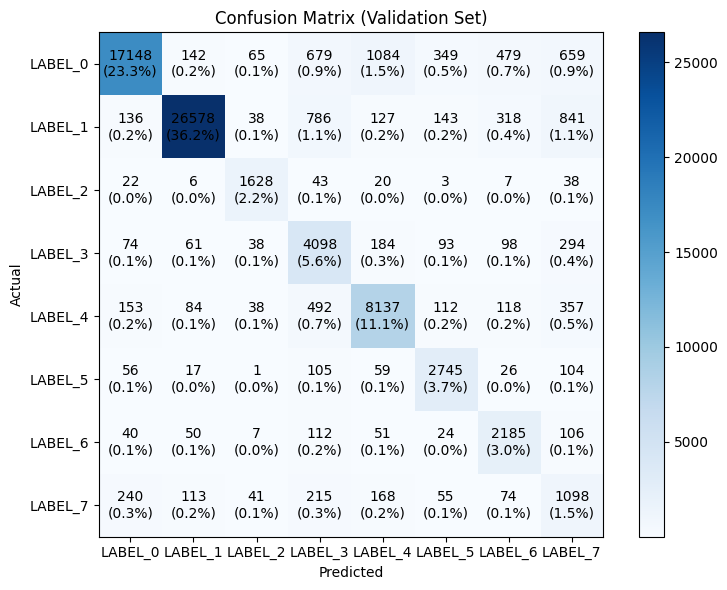

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# --- Use labels directly from your StringIndexerModel
class_labels = label_indexer.labels  

# --- Collect predictions into Pandas
val_results = val_predictions.select("label_indexed", "prediction").toPandas()
y_true = val_results["label_indexed"].astype(int).values
y_pred = val_results["prediction"].astype(int).values

# --- Classification Report with your fixed labels
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# --- Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, cmap="Blues")

# --- Add annotations: count + percentage (global)
cm_sum = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = cm[i, j] / cm_sum * 100
        ax.text(j, i, f"{count}\n({percent:.1f}%)",
                ha="center", va="center", color="black")

# --- Axis setup with fixed labels
ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Validation Set)")

plt.colorbar(im)
plt.tight_layout()
plt.show()


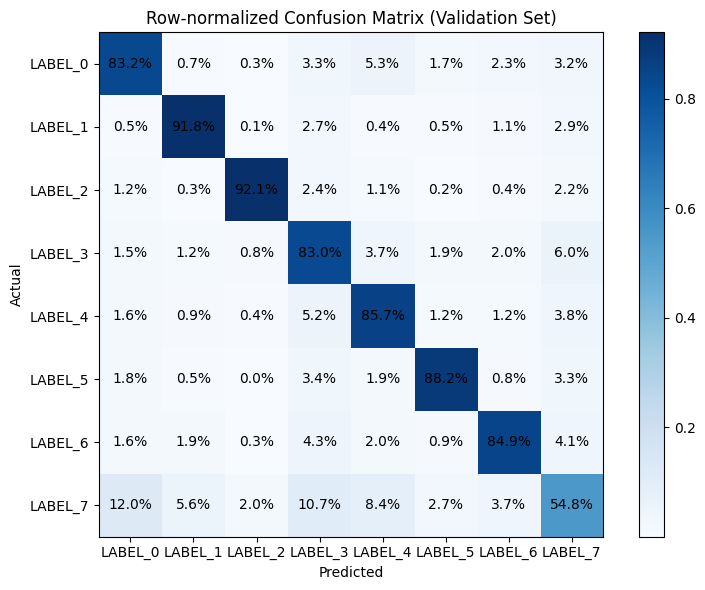

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# --- Confusion Matrix (row-normalized)
cm = confusion_matrix(y_true, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, cmap="Blues")

# --- Annotate with % values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]*100:.1f}%",
                ha="center", va="center", color="black")

# --- Axis setup with fixed labels
ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Row-normalized Confusion Matrix (Validation Set)")

plt.colorbar(im)
plt.tight_layout()
plt.show()


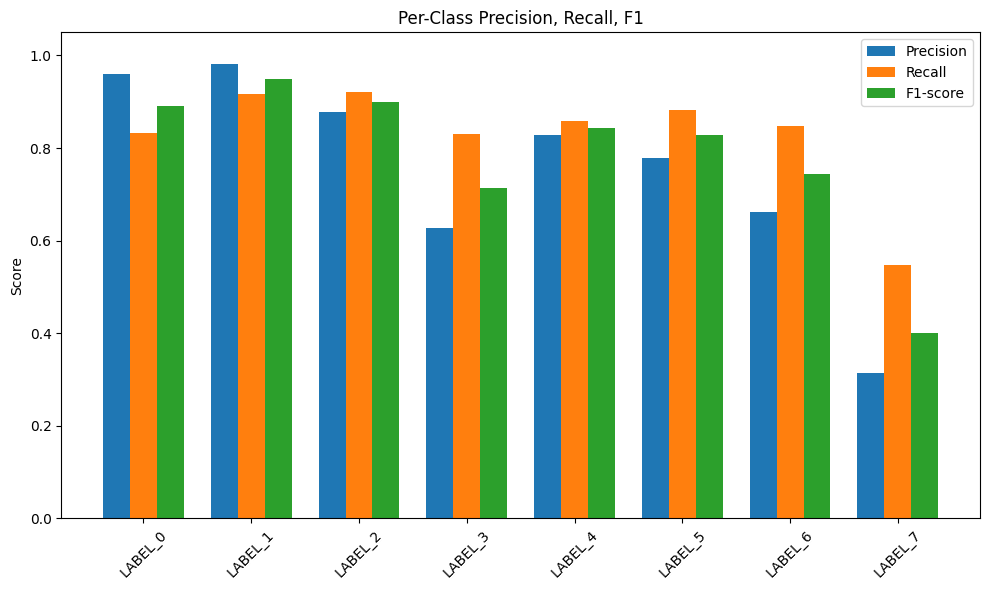

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# --- Calculate per-class metrics
prec, rec, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=range(len(class_labels)))

x = np.arange(len(class_labels))  # class positions

plt.figure(figsize=(10,6))
plt.bar(x - 0.25, prec, width=0.25, label="Precision")
plt.bar(x, rec, width=0.25, label="Recall")
plt.bar(x + 0.25, f1, width=0.25, label="F1-score")

plt.xticks(x, class_labels, rotation=45)
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.title("Per-Class Precision, Recall, F1")
plt.legend()
plt.tight_layout()
plt.show()


**PERFROMANCE ANALYSIS BY CONTRACT TYPE-LOGISTIC REGRESSION**

**SparkNLP LegalBERT Classifier Pipeline**

In [ ]:
from sparknlp.base import DocumentAssembler
from sparknlp.annotator import BertSentenceEmbeddings, ClassifierDLApproach
from pyspark.ml import Pipeline

document = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

# Sentence-level Legal BERT embeddings — no tokenization or pooling needed
sentence_embeddings = BertSentenceEmbeddings.pretrained(
    "sent_bert_base_uncased_legal", "en"
).setInputCols(["document"]) \
 .setOutputCol("sentence_embeddings")

classifier = ClassifierDLApproach() \
    .setInputCols(["sentence_embeddings"]) \
    .setOutputCol("class") \
    .setLabelColumn("type_label") \
    .setBatchSize(64) \
    .setMaxEpochs(50) \
    .setLr(1e-5) \
    .setDropout(0.2) \
    .setWeightCol("class_weight") \
    .setEnableOutputLogs(True)

nlp_pipeline = Pipeline(stages=[
    document,
    sentence_embeddings,
    classifier
])


sent_bert_base_uncased_legal download started this may take some time.
Approximate size to download 390.8 MB
[ | ]

25/09/02 12:08:41 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.
25/09/02 12:08:41 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.


sent_bert_base_uncased_legal download started this may take some time.
Approximate size to download 390.8 MB
Download done! Loading the resource.
[ — ]

2025-09-02 12:08:47.471773: W external/org_tensorflow/tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


[OK!]


In [20]:
modern_model = nlp_pipeline.fit(train_df)

val_predictions = modern_model.transform(val_df)

25/09/02 12:08:56 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/09/02 13:11:32 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/09/02 13:11:33 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
25/09/02 13:11:33 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
2025-09-02 14:00:42.669572: I external/org_tensorflow/tensorflow/cc/saved_model/reader.cc:43] Reading SavedModel from: /var/folders/6q/bqk5wgh97kx17wtj7dl1l3zw0000gn/T/c978365222ab_classifier_dl15631572983522796044
2025-09-02 14:00:42.710063: I external/org_tensorflow/tensorflow/cc/saved_model/reader.cc:107] Reading meta graph with tags { serve }
2025-09-02 14:00:42.710081: I external/org_tensorflow/tensorflow/cc/saved_model/reader.cc:148] Reading SavedModel debug info (if present) from: /var/folders/6q/bqk5wgh97kx17wtj7dl1l3zw0000gn/T/c978365222ab_classifier_dl15631572983522796044
2025-09-02 14:00:42.882356: I external/org_tensorflow/tensorflow/cc

Training started - epochs: 20 - learning_rate: 1.0E-4 - batch_size: 64 - training_examples: 220958 - classes: 8
Epoch 1/20 - 15.29s - loss: 6021.1265 - acc: 0.54774857 - batches: 3453
Epoch 2/20 - 14.82s - loss: 5828.239 - acc: 0.604425 - batches: 3453
Epoch 3/20 - 14.50s - loss: 5775.0586 - acc: 0.61482716 - batches: 3453
Epoch 4/20 - 14.88s - loss: 5747.793 - acc: 0.6196613 - batches: 3453
Epoch 5/20 - 14.64s - loss: 5732.4014 - acc: 0.62274826 - batches: 3453
Epoch 6/20 - 14.62s - loss: 5722.914 - acc: 0.6246946 - batches: 3453
Epoch 7/20 - 14.73s - loss: 5716.398 - acc: 0.62624264 - batches: 3453
Epoch 8/20 - 14.53s - loss: 5709.4775 - acc: 0.6273561 - batches: 3453
Epoch 9/20 - 14.45s - loss: 5682.52 - acc: 0.6477196 - batches: 3453
Epoch 10/20 - 14.71s - loss: 5663.9834 - acc: 0.653536 - batches: 3453
Epoch 11/20 - 14.69s - loss: 5651.941 - acc: 0.6547762 - batches: 3453
Epoch 12/20 - 14.59s - loss: 5643.0986 - acc: 0.6557947 - batches: 3453
Epoch 13/20 - 14.49s - loss: 5636.111 

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

val_results = val_predictions.select("type_label", "class.result").toPandas()
val_results["prediction"] = val_results["result"].apply(lambda x: x[0])

y_true = val_results["type_label"]
y_pred = val_results["prediction"]

print(classification_report(y_true, y_pred, digits=4))

25/09/02 14:06:32 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
/Users/jefferyjapheth/miniconda3/envs/sparknlp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

     LABEL_0     0.5900    0.8683    0.7026     20605
     LABEL_1     0.7675    0.9475    0.8480     28967
     LABEL_2     0.0000    0.0000    0.0000      1767
     LABEL_3     0.0000    0.0000    0.0000      4940
     LABEL_4     0.4953    0.3849    0.4332      9491
     LABEL_5     0.0000    0.0000    0.0000      3113
     LABEL_6     0.0000    0.0000    0.0000      2575
     LABEL_7     0.0000    0.0000    0.0000      2004

    accuracy                         0.6669     73462
   macro avg     0.2316    0.2751    0.2480     73462
weighted avg     0.5321    0.6669    0.5874     73462



/Users/jefferyjapheth/miniconda3/envs/sparknlp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jefferyjapheth/miniconda3/envs/sparknlp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [32]:
cm = confusion_matrix(y_true, y_pred, labels=modern_model.stages[-1].getLabels())
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cmn, annot=True, fmt=".2f", xticklabels=modern_model.stages[-1].getLabels(),
            yticklabels=model.stages[-1].getLabels(), cmap="Blues")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix (Validation Set)")
plt.show()

AttributeError: 'ClassifierDLModel' object has no attribute 'getLabels'

In [38]:
from sparknlp.base import DocumentAssembler, TokenAssembler
from sparknlp.annotator import (
    Tokenizer,
    BertEmbeddings,
    SentenceEmbeddings,
    ClassifierDLApproach
)
from pyspark.ml import Pipeline

# Step 1: Document assembler
document = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

# Step 2: Tokenizer
tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("token")

# Step 3: Token-level BERT embeddings
bert_embeddings = BertEmbeddings.pretrained("bert_base_uncased", "en") \
    .setInputCols(["document", "token"]) \
    .setOutputCol("bert_embeddings") \
    .setCaseSensitive(False)

# Step 4: Pool token embeddings into sentence embeddings
sentence_embeddings = SentenceEmbeddings() \
    .setInputCols(["document", "bert_embeddings"]) \
    .setOutputCol("sentence_embeddings") \
    .setPoolingStrategy("MAX")  

# Step 5: Classifier
classifier = ClassifierDLApproach() \
    .setInputCols(["sentence_embeddings"]) \
    .setOutputCol("class") \
    .setLabelColumn("type_label") \
    .setBatchSize(16) \
    .setMaxEpochs(50) \
    .setLr(3e-5) \
    .setDropout(0.3) \
    .setEnableOutputLogs(True)

# Pipeline
nlp_pipeline = Pipeline(stages=[
    document,
    tokenizer,
    bert_embeddings,
    sentence_embeddings,
    classifier
])

ConnectionRefusedError: [Errno 61] Connection refused

### Fit on train_df + validate on val_df

### Evaluate validation set

### Final test evaluation

### Save model

## BERT + LogisticRegression

In [ ]:
from sparknlp.base import DocumentAssembler
from sparknlp.annotator import Tokenizer, BertEmbeddings
from pyspark.ml import Pipeline

# 1. Assemble document
document = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

# 2. Tokenize
tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("token")

# 3. Load pretrained LegalBERT embeddings
embeddings = BertEmbeddings.pretrained("legal_bert_base_uncased", "en") \
    .setInputCols(["document", "token"]) \
    .setOutputCol("embeddings") \
    .setCaseSensitive(False)

# 4. Pool word embeddings to sentence/document level
sentence_embeddings = SentenceEmbeddings() \
    .setInputCols(["document", "embeddings"]) \
    .setOutputCol("sentence_embeddings") \
    .setPoolingStrategy("AVERAGE")

# 5. Convert to ML Vector format
embeddings_finisher = EmbeddingsFinisher() \
    .setInputCols(["sentence_embeddings"]) \
    .setOutputCols(["features"]) \
    .setOutputAsVector(True)

# 6. ML Classifier
classifier = LogisticRegression() \
    .setFeaturesCol("features") \
    .setLabelCol("type_label")

# Complete pipeline
complete_pipeline = Pipeline(stages=[
    document, tokenizer, embeddings, 
    sentence_embeddings, embeddings_finisher, classifier
])



# Run pipeline
model = pipeline.fit(df)
result = model.transform(df)

# Show tokens + embeddings
result.selectExpr("token.result as tokens", "embeddings.embeddings as embeddings").show()


## BERT + ClassifierDL

In [ ]:
from sparknlp.annotator import *
from sparknlp.base import *
from pyspark.ml import Pipeline

# Document assembler
document = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

# Tokenizer
tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("token")

# Pretrained LegalBERT embeddings
embeddings = BertEmbeddings.pretrained("legal_bert_base_uncased", "en") \
    .setInputCols(["document", "token"]) \
    .setOutputCol("embeddings") \
    .setCaseSensitive(False)

# Sentence embeddings (pool word embeddings → sentence/document vector)
sentence_embeddings = SentenceEmbeddings() \
    .setInputCols(["document", "embeddings"]) \
    .setOutputCol("sentence_embeddings") \
    .setPoolingStrategy("AVERAGE")

# Neural classifier
classifier = ClassifierDLApproach() \
    .setInputCols(["sentence_embeddings"]) \
    .setOutputCol("class") \
    .setLabelColumn("type_label") \
    .setBatchSize(64) \
    .setMaxEpochs(20) \
    .setLr(1e-3) \
    .setEnableOutputLogs(True)

# Build pipeline
bert_classifierdl_pipeline = Pipeline(stages=[
    document,
    tokenizer,
    embeddings,
    sentence_embeddings,
    classifier
])

## USE + ClassifierDL pipeline

In [ ]:
# Alternative: USE + ClassifierDL pipeline
document_use = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

use_embeddings = UniversalSentenceEncoder.pretrained("tfhub_use", "en") \
    .setInputCols(["document"]) \
    .setOutputCol("sentence_embeddings")

classifier_use = ClassifierDLApproach() \
    .setInputCols(["sentence_embeddings"]) \
    .setOutputCol("class") \
    .setLabelColumn("type_label") \
    .setBatchSize(64) \
    .setMaxEpochs(15) \
    .setLr(1e-3) \
    .setEnableOutputLogs(True)

use_classifierdl_pipeline = Pipeline(stages=[
    document_use,
    use_embeddings,
    classifier_use
])

In [39]:
spark.stop()

ConnectionRefusedError: [Errno 61] Connection refused